In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast

file = pd.read_excel('C:/Data_/excel/data_jobs_salary_all.xlsx',sheet_name='maaz_1')
file['job_posted_month']=pd.to_datetime(file['job_posted_date']).dt.strftime('%b')
file['job_skills']=file['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

print(file.info())

<class 'pandas.DataFrame'>
RangeIndex: 32672 entries, 0 to 32671
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   job_title_short        32672 non-null  str           
 1   job_title              32672 non-null  str           
 2   job_location           32317 non-null  str           
 3   job_via                32662 non-null  str           
 4   job_schedule_type      32531 non-null  str           
 5   job_work_from_home     32672 non-null  bool          
 6   search_location        32672 non-null  str           
 7   job_posted_date        32672 non-null  datetime64[us]
 8   job_no_degree_mention  32672 non-null  bool          
 9   job_health_insurance   32672 non-null  bool          
 10  job_country            32672 non-null  str           
 11  salary_rate            32672 non-null  str           
 12  salary_year_avg        22036 non-null  float64       
 13  salary_hour_

In [36]:
file_DA_USA=file[(file['job_title_short']=='Data Analyst')&(file['job_country']=='United States')]
file_DA_USA=file_DA_USA.dropna(subset=['salary_year_avg'])
file_DA_USA['salary_year_avg'].sample(10)


26958    200000.000000
28470     92500.000000
26062     64395.203125
32127     57500.000000
8366      63000.000000
23775     87500.000000
31487     80000.000000
19040     82000.000000
16480     75000.000000
22404    125000.000000
Name: salary_year_avg, dtype: float64

<Axes: >

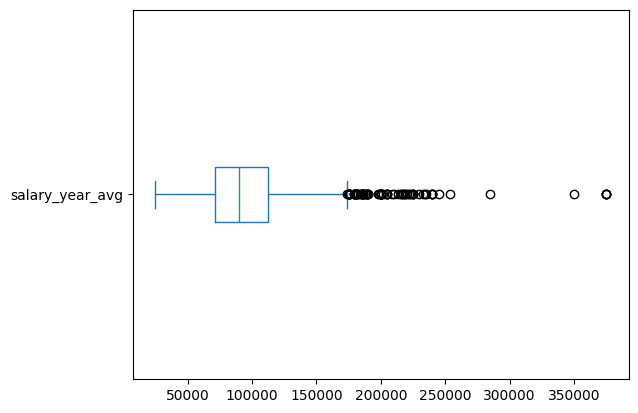

In [37]:
file_DA_USA['salary_year_avg'].plot(kind='box',vert=False)

{'whiskers': [<matplotlib.lines.Line2D at 0x19ddde59e10>,
 'caps': [<matplotlib.lines.Line2D at 0x19ddde5b1d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x19ddde59550>],
 'medians': [<matplotlib.lines.Line2D at 0x19ddde185d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x19ddde18ed0>],
 'means': []}

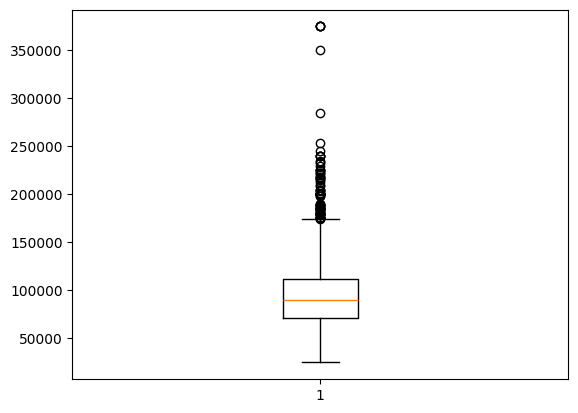

In [38]:
#OR
plt.boxplot(file_DA_USA['salary_year_avg'])

C:\Users\Maaz\AppData\Local\Temp\ipykernel_14092\1453966151.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list,labels=job_titles,vert=False)


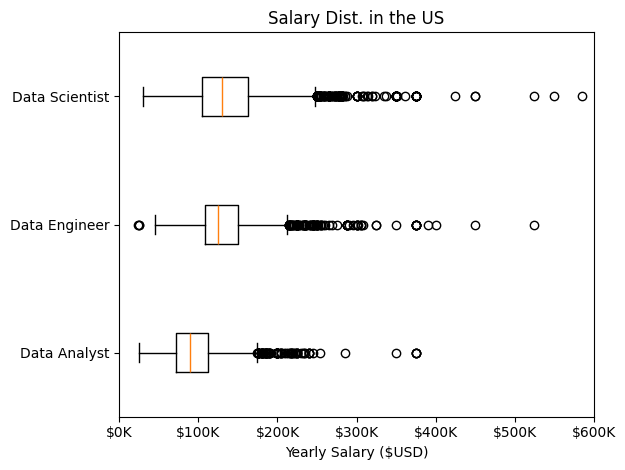

In [50]:
job_titles=['Data Analyst','Data Engineer','Data Scientist']
file_US=file[(file['job_title_short'].isin(job_titles)) & (file['job_country']=='United States')].copy()
file_US=file_US.dropna(subset=['salary_year_avg'])
job_list=[file_US[file_US['job_title_short']==job_title]['salary_year_avg']for job_title in job_titles]
plt.boxplot(job_list,labels=job_titles,vert=False)
plt.xlim(0,600000)
plt.xlabel('Yearly Salary ($USD)')
plt.title('Salary Dist. in the US')
plt.tight_layout()
ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos:f'${int(x/1000)}K'))
plt.show()

ValueError: ('Lengths must match to compare', (19766,), (3,))